In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [3]:
df = pd.read_csv("healthcare.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
# since the BMI is right skewed and about 201 out of 5000 we will use median imputation 
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [5]:
# Splitting the dataset into independent and dependent features

X = df.drop(columns=['stroke'], axis=1)
y = df['stroke']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

print(numerical_features)
print(categorical_features)

['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [8]:
#numerical features piepline 
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

#categorical features pipeline 
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


#column transformer 
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

In [9]:
preprocessor.fit_transform(X_train)

array([[-1.48974572,  1.58415472, -0.32198091, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.9372468 ,  0.82970766, -0.32198091, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.86386831, -0.98984115, -0.32198091, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.23225557, -1.87032526, -0.32198091, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.20713926,  1.62853396, -0.32198091, ...,  1.        ,
         0.        ,  0.        ],
       [-0.35311426,  0.11963983, -0.32198091, ...,  0.        ,
         0.        ,  1.        ]])

In [32]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000,class_weight='balanced'),
    "Decision Tree":DecisionTreeClassifier(random_state=42,class_weight='balanced'),
    "Random Forest":RandomForestClassifier(random_state=42,class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost":XGBClassifier(eval_metric="logloss",random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0,random_state=42)

}

In [33]:
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "f1 score " : f1_score(y_test,y_pred)
    })

c:\Users\ANUP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ANUP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,f1 score
0,Logistic Regression,0.745597,0.167785,0.806452,0.277778
1,Decision Tree,0.912916,0.200000,0.145161,0.168224
2,Random Forest,0.939335,0.000000,0.000000,0.000000
3,Gradient Boosting,0.938356,0.000000,0.000000,0.000000
4,AdaBoost,0.939335,0.000000,0.000000,0.000000
5,XGBoost,0.934442,0.333333,0.080645,0.129870
6,CatBoost,0.937378,0.000000,0.000000,0.000000


### why recall is zero because the dataset is highly imbalanced. 
### since this is synthetic data we are going to keep them as it is 

In [36]:
#applying the smote to handle the imbalanced dataset
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
) 


In [37]:
print("Before SMOTE")
print(Counter(y_train))

print("\nAfter SMOTE")
print(Counter(y_train_smote))

Before SMOTE
Counter({0: 3901, 1: 187})

After SMOTE
Counter({0: 3901, 1: 3901})


In [38]:
results_smote = []

for name, model in models.items():

    print(f"Training {name}")

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_processed)

    results_smote.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

Training Logistic Regression
Training Decision Tree
Training Random Forest
Training Gradient Boosting
Training AdaBoost
Training XGBoost
Training CatBoost


In [46]:
results_smote_df = pd.DataFrame(results_smote)

results_smote_df.sort_values(by='Accuracy',ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.923679,0.100000,0.032258,0.048780
5,XGBoost,0.921722,0.050000,0.016129,0.024390
6,CatBoost,0.920744,0.172414,0.080645,0.109890
3,Gradient Boosting,0.882583,0.146341,0.193548,0.166667
1,Decision Tree,0.863014,0.102041,0.161290,0.125000
4,AdaBoost,0.786693,0.177686,0.693548,0.282895
0,Logistic Regression,0.751468,0.171233,0.806452,0.282486


### AdaBoost has the best F1-score, balancing precision and recall slightly better than Logistic Regression.

In [50]:
#hyperparameter tunnig the adaboost

param_grid = {
    'n_estimators':[50,100,200,300,350],
    'learning_rate':[0.01,0.05,0.1,0.5,1]
}

ada = AdaBoostClassifier(random_state=42)

rad_search = RandomizedSearchCV(estimator=ada,param_distributions=param_grid,n_iter=20,cv=5,scoring='f1',random_state=42,n_jobs=-1)

rad_search.fit(X_train_smote,y_train_smote)

print(rad_search.best_params_)
print(rad_search.best_score_)

{'n_estimators': 300, 'learning_rate': 1}
0.9043509929595819


In [53]:
print(rad_search.best_estimator_)

AdaBoostClassifier(learning_rate=1, n_estimators=300, random_state=42)


In [55]:
y_pred = rad_search.predict(X_test_processed)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.89      0.92       960
           1       0.15      0.31      0.20        62

    accuracy                           0.85      1022
   macro avg       0.55      0.60      0.56      1022
weighted avg       0.90      0.85      0.88      1022



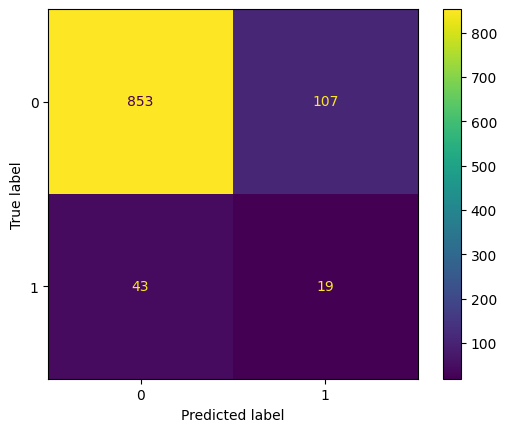

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

#### The SMOTE AdaBoost before tuning actually had better Recall (0.69) and F1 (0.28) than the tuned model on the test set.

#### hyperparameter tunning the logistic regression + smote and comparing

In [57]:
lr = LogisticRegression(max_iter=1000)

param_grid = {
    "C": [0.001,0.01,0.1,1,10,100],
    "solver": ["liblinear","lbfgs"],
    "penalty": ["l2"],
    "class_weight": [None,"balanced"]
}

search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_smote, y_train_smote)

print(search.best_params_)
print(search.best_score_)

{'solver': 'liblinear', 'penalty': 'l2', 'class_weight': None, 'C': 0.01}
0.8048943489393204


In [59]:
best_lr = search.best_estimator_

In [60]:
y_pred = best_lr.predict(X_test_processed)

In [61]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.74      0.85       960
           1       0.17      0.82      0.28        62

    accuracy                           0.75      1022
   macro avg       0.58      0.78      0.56      1022
weighted avg       0.94      0.75      0.81      1022



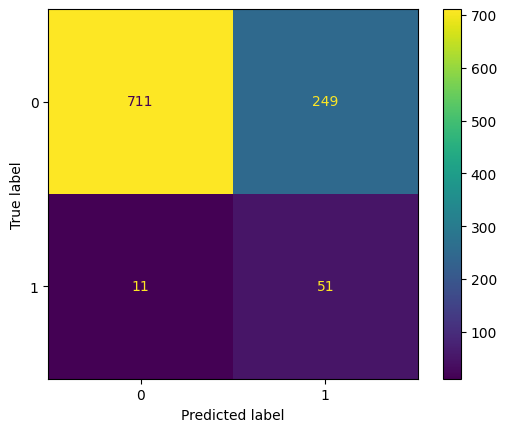

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

#### ok the logistic regression is perfroming better than adaboost 

#### the model says that - "I'd rather send more healthy patients for additional testing than miss someone who actually has a stroke"
#### which is accepted in medical feild (systems)

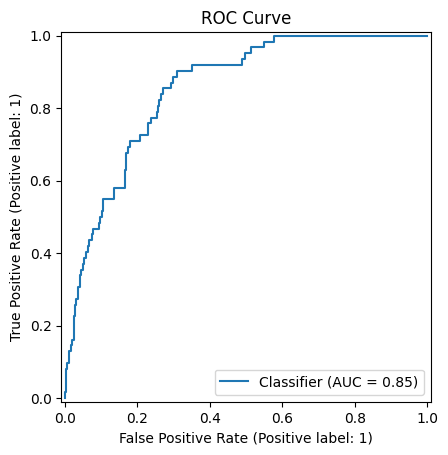

In [65]:
#roc-auc score
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test,y_prob)
plt.title("ROC Curve")
plt.show()

In [66]:
#saving the model
import joblib

joblib.dump(best_lr, "stroke_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [67]:
#prediction fucntion
def predict_stroke(data):

    processed = preprocessor.transform(data)
    prediction = best_lr.predict(processed)
    probability = best_lr.predict_proba(processed)

    return prediction, probability